# FDFK2D I/O Performance Benchmark

Compares trace read/write performance across formats in **FDFK2D-Python** ([`fk/io_fortran.py`](../fk/io_fortran.py)).

## Coverage

| Section | Content |
|---------|---------|
| 4 Write | SU loop/vectorized, NPY, NPZ; compressed HDF5/NPZ only if array ≤ 50 MB |
| 5 Read | Full load, NPY mmap / mmap+touch, `read_traces()` |
| 6 Round-trip | write→read latency and float32 fidelity |
| 7 Disk size | On-disk bytes vs RAM |
| 8–9 | Plots and summary table |


## 1. Formats under test

**SU** - 240-byte header + float32 samples; loop vs vectorized.

**NPY** - raw array + `_dt.npy`; optional memory map.

**NPZ** - uncompressed or DEFLATE-compressed archive.

**HDF5** - optional; none / LZF / gzip compression.

**`read_traces()`** - dispatches by file extension.


## 2. Benchmark methodology

- `time.perf_counter()`, 1 warmup + 5 timed repeats (median ± std).
- Throughput = `array.nbytes / time` (MB/s).
- **`NPY (mmap)`** maps only; **`NPY (mmap+touch)`** forces a full read.
- **Skip rule**: if estimated array size **> 50 MB**, skip compression-heavy writers/readers (`NPZ compressed`, `HDF5 LZF/gzip`) that are predictably slow on multi‑MB random data.


In [1]:
import sys
import os
import time
import tempfile
import shutil
import platform
from pathlib import Path
from dataclasses import dataclass
from typing import Callable, Any

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps

sys.path.insert(0, os.path.abspath(".."))

from fk.io_fortran import (
    _read_su_loop,
    read_su,
    _write_su_loop,
    write_su,
    write_npz,
    read_npz,
    write_npy,
    read_npy,
    write_hdf5,
    read_hdf5,
    read_traces,
)

print(f"Platform : {platform.system()} {platform.machine()}")
print(f"Python   : {sys.version.split()[0]}")
print(f"NumPy    : {np.__version__}")
try:
    import h5py

    print(f"h5py     : {h5py.__version__}")
except ImportError:
    print("h5py     : not installed - HDF5 benchmarks will be skipped")
    h5py = None


Platform : Darwin arm64
Python   : 3.12.13
NumPy    : 1.26.4
h5py     : 3.16.0


## 3. Test data sizes

| Label | Shape | Notes |
|-------|-------|-------|
| small | 100 x 4501 | Smoke test |
| medium | 5000 x 4501 | ~90 MB RAM |
| large | 100000 x 4501 | ~1.8 GB RAM |
| FDFK2D | 500 x 8001 | 500 stations, tmax=80 s, dt=0.01 |

Random float32 data (poorly compressible). **Large** requires sufficient RAM and disk.


In [2]:
DT_SEC = 0.01
N_WARMUP = 1
N_REPEAT = 5

FDFK_TMAX = 80.0
FDFK_NTR = 500
FDFK_NS = int(round(FDFK_TMAX / DT_SEC)) + 1

SIZES = {
    "small (100x4501)": (100, 4501),
    "medium (5000x4501)": (5000, 4501),
    "large (100000x4501)": (100_000, 4501),
    f"FDFK2D ({FDFK_NTR}x{FDFK_NS})": (FDFK_NTR, FDFK_NS),
}

rng = np.random.default_rng(42)
datasets: dict[str, np.ndarray] = {}
for label, (ntr, ns) in SIZES.items():
    arr = rng.standard_normal((ntr, ns), dtype=np.float32)
    datasets[label] = arr
    mb = arr.nbytes / 1e6
    gb = arr.nbytes / 1e9
    size_str = f"{gb:7.2f} GB" if gb >= 1.0 else f"{mb:7.2f} MB"
    print(f"{label:30s}  {ntr:6d} traces x {ns:5d} samples  = {size_str} (RAM)")


small (100x4501)                   100 traces x  4501 samples  =    1.80 MB (RAM)
medium (5000x4501)                5000 traces x  4501 samples  =   90.02 MB (RAM)
large (100000x4501)             100000 traces x  4501 samples  =    1.80 GB (RAM)
FDFK2D (500x8001)                  500 traces x  8001 samples  =   16.00 MB (RAM)


In [3]:
@dataclass
class BenchResult:
    median_s: float
    std_s: float
    last: Any = None

    @property
    def median_ms(self) -> float:
        return self.median_s * 1e3

    def throughput_mbs(self, nbytes: int) -> float:
        return (nbytes / 1e6) / self.median_s


def bench(func, *args, n_warmup=N_WARMUP, n_repeat=N_REPEAT, **kwargs) -> BenchResult:
    last = None
    for _ in range(n_warmup):
        last = func(*args, **kwargs)
    times = []
    for _ in range(n_repeat):
        t0 = time.perf_counter()
        last = func(*args, **kwargs)
        times.append(time.perf_counter() - t0)
    return BenchResult(float(np.median(times)), float(np.std(times)), last=last)


def write_npz_compressed(path, data, dt_sec):
    data = np.atleast_2d(np.asarray(data, dtype=np.float32))
    np.savez_compressed(str(Path(path)), data=data, dt=np.float64(dt_sec))


def read_npy_materialize(path):
    data, dt_sec = read_npy(path, mmap_mode="r")
    _ = float(np.sum(data))
    return data, dt_sec


def on_disk_bytes(path: Path) -> int:
    path = Path(path)
    if path.suffix == ".npy":
        dt_path = path.with_name(path.stem + "_dt.npy")
        return path.stat().st_size + dt_path.stat().st_size
    return path.stat().st_size


# Skip compression-heavy formats when array RAM exceeds this threshold.
SLOW_COMPRESS_MB = 50.0
SLOW_COMPRESS_METHODS = frozenset({
    "NPZ (compressed)",
    "HDF5 (LZF)",
    "HDF5 (gzip)",
})


def skip_slow_compress(nbytes: int) -> bool:
    """True when compressed benchmarks should be skipped for this array size."""
    return (nbytes / 1e6) > SLOW_COMPRESS_MB


def methods_for_dataset(methods: dict[str, Callable], nbytes: int) -> dict[str, Callable]:
    """Drop slow compression methods for large arrays."""
    if not skip_slow_compress(nbytes):
        return methods
    return {k: v for k, v in methods.items() if k not in SLOW_COMPRESS_METHODS}


# Okabe-Ito colorblind-friendly palette
METHOD_COLORS: dict[str, str] = {}
_PALETTE = [
    "#0072B2", "#E69F00", "#009E73", "#D55E00",
    "#CC79A7", "#56B4E9", "#F0E442", "#000000",
    "#882255", "#44AA99", "#999999", "#661100",
]


def register_method_colors(methods: list[str]) -> None:
    for i, m in enumerate(methods):
        METHOD_COLORS[m] = _PALETTE[i % len(_PALETTE)]


## 4. Trace write benchmark

SU loop is the **legacy baseline**.


In [4]:
tmpdir = Path(tempfile.mkdtemp(prefix="io_bench_"))
print(f"Temp directory: {tmpdir}")


def _slug(label: str) -> str:
    return label.split()[0].lower()


write_methods: dict[str, Callable] = {
    "SU (loop)": lambda p, d: _write_su_loop(p.with_suffix(".su"), d, DT_SEC),
    "SU (vectorized)": lambda p, d: write_su(p.with_suffix(".su"), d, DT_SEC),
    "NPY": lambda p, d: write_npy(p.with_suffix(".npy"), d, DT_SEC),
    "NPZ": lambda p, d: write_npz(p.with_suffix(".npz"), d, DT_SEC),
    "NPZ (compressed)": lambda p, d: write_npz_compressed(p.with_suffix(".npz"), d, DT_SEC),
}
if h5py is not None:
    write_methods["HDF5 (none)"] = lambda p, d: write_hdf5(p.with_suffix(".h5"), d, DT_SEC, compression=None)
    write_methods["HDF5 (LZF)"] = lambda p, d: write_hdf5(p.with_suffix(".h5"), d, DT_SEC, compression="lzf")
    write_methods["HDF5 (gzip)"] = lambda p, d: write_hdf5(p.with_suffix(".h5"), d, DT_SEC, compression="gzip")

write_results: dict[str, dict[str, BenchResult]] = {}
written_paths: dict[str, dict[str, Path]] = {}

for size_label, data in datasets.items():
    write_results[size_label] = {}
    written_paths[size_label] = {}
    mb = data.nbytes / 1e6
    gb = data.nbytes / 1e9
    ram = f"{gb:.2f} GB" if gb >= 1.0 else f"{mb:.2f} MB"
    print(f"\n--- Write: {size_label} ({ram} RAM) ---")
    active = methods_for_dataset(write_methods, data.nbytes)
    if skip_slow_compress(data.nbytes):
        skipped = sorted(SLOW_COMPRESS_METHODS & write_methods.keys())
        print(f"  [skip > {SLOW_COMPRESS_MB:.0f} MB: {', '.join(skipped)}]")
    for method_name, writer in active.items():
        stem = tmpdir / f"{_slug(size_label)}_{method_name.replace(' ', '_').replace('(', '').replace(')', '')}"
        br = bench(writer, stem, data)
        write_results[size_label][method_name] = br
        if "NPY" in method_name and "NPZ" not in method_name:
            fpath = stem.with_suffix(".npy")
        elif "SU" in method_name:
            fpath = stem.with_suffix(".su")
        elif "NPZ" in method_name:
            fpath = stem.with_suffix(".npz")
        else:
            fpath = stem.with_suffix(".h5")
        written_paths[size_label][method_name] = fpath
        tp = br.throughput_mbs(data.nbytes)
        print(f"  {method_name:22s}  {br.median_ms:8.2f} ± {br.std_s*1e3:5.2f} ms  ({tp:8.1f} MB/s)")


Temp directory: /var/folders/ln/v188ylkn2qq1nqsd7wyj2w9m0000gn/T/io_bench_p73qtc97

--- Write: small (100x4501) (1.80 MB RAM) ---
  SU (loop)                   0.58 ±  0.01 ms  (  3117.6 MB/s)
  SU (vectorized)             0.52 ±  0.06 ms  (  3456.8 MB/s)
  NPY                         0.43 ±  0.04 ms  (  4161.2 MB/s)
  NPZ                         0.60 ±  0.03 ms  (  2994.0 MB/s)
  NPZ (compressed)           51.33 ±  0.33 ms  (    35.1 MB/s)
  HDF5 (none)                 0.56 ±  0.09 ms  (  3242.0 MB/s)
  HDF5 (LZF)                 10.25 ±  0.13 ms  (   175.6 MB/s)
  HDF5 (gzip)                26.99 ±  0.51 ms  (    66.7 MB/s)

--- Write: medium (5000x4501) (90.02 MB RAM) ---
  [skip > 50 MB: HDF5 (LZF), HDF5 (gzip), NPZ (compressed)]
  SU (loop)                  35.79 ±  0.53 ms  (  2514.9 MB/s)
  SU (vectorized)            24.36 ±  3.69 ms  (  3694.8 MB/s)
  NPY                        11.92 ±  7.99 ms  (  7551.7 MB/s)
  NPZ                        20.50 ±  1.13 ms  (  4391.0 MB/s)
  HD

## 5. Trace read benchmark


In [5]:
read_methods: dict[str, Callable] = {
    "SU (loop)": lambda p: _read_su_loop(p),
    "SU (vectorized)": lambda p: read_su(p),
    "NPY": lambda p: read_npy(p),
    "NPY (mmap)": lambda p: read_npy(p, mmap_mode="r"),
    "NPY (mmap+touch)": read_npy_materialize,
    "NPZ": lambda p: read_npz(p),
    "NPZ (compressed)": lambda p: read_npz(p),
    "read_traces (SU)": lambda p: read_traces(p),
    "read_traces (NPY)": lambda p: read_traces(p),
}
if h5py is not None:
    read_methods["HDF5 (none)"] = lambda p: read_hdf5(p)
    read_methods["HDF5 (LZF)"] = lambda p: read_hdf5(p)
    read_methods["HDF5 (gzip)"] = lambda p: read_hdf5(p)
    read_methods["read_traces (HDF5)"] = lambda p: read_traces(p)

read_path_map = {
    "SU (loop)": "SU (loop)",
    "SU (vectorized)": "SU (vectorized)",
    "NPY": "NPY",
    "NPY (mmap)": "NPY",
    "NPY (mmap+touch)": "NPY",
    "NPZ": "NPZ",
    "NPZ (compressed)": "NPZ (compressed)",
    "HDF5 (none)": "HDF5 (none)",
    "HDF5 (LZF)": "HDF5 (LZF)",
    "HDF5 (gzip)": "HDF5 (gzip)",
    "read_traces (SU)": "SU (vectorized)",
    "read_traces (NPY)": "NPY",
    "read_traces (HDF5)": "HDF5 (LZF)",
}

read_results: dict[str, dict[str, BenchResult]] = {}

for size_label, data in datasets.items():
    read_results[size_label] = {}
    mb = data.nbytes / 1e6
    gb = data.nbytes / 1e9
    ram = f"{gb:.2f} GB" if gb >= 1.0 else f"{mb:.2f} MB"
    print(f"\n--- Read: {size_label} ({ram} RAM) ---")
    active_read = methods_for_dataset(read_methods, data.nbytes)
    if skip_slow_compress(data.nbytes):
        skipped = sorted(SLOW_COMPRESS_METHODS & read_methods.keys())
        if "read_traces (HDF5)" in read_methods:
            skipped.append("read_traces (HDF5)")
        print(f"  [skip > {SLOW_COMPRESS_MB:.0f} MB: {', '.join(skipped)}]")
    for method_name, reader in active_read.items():
        if method_name == "read_traces (HDF5)" and skip_slow_compress(data.nbytes):
            continue
        if method_name not in read_path_map:
            continue
        wkey = read_path_map[method_name]
        if wkey not in written_paths[size_label]:
            continue
        fpath = written_paths[size_label][wkey]
        reader(fpath)
        br = bench(reader, fpath)
        read_results[size_label][method_name] = br
        tp = br.throughput_mbs(data.nbytes)
        print(
            f"  {method_name:24s}  {br.median_ms:8.2f} ± {br.std_s*1e3:5.2f} ms  "
            f"({tp:8.1f} MB/s)"
        )



--- Read: small (100x4501) (1.80 MB RAM) ---
  SU (loop)                     0.56 ±  0.10 ms  (  3242.7 MB/s)
  SU (vectorized)               0.30 ±  0.12 ms  (  6018.9 MB/s)
  NPY                           0.22 ±  0.03 ms  (  8374.0 MB/s)
  NPY (mmap)                    0.16 ±  0.01 ms  ( 11335.1 MB/s)
  NPY (mmap+touch)              0.36 ±  0.06 ms  (  4974.1 MB/s)
  NPZ                           0.40 ±  0.04 ms  (  4505.2 MB/s)
  NPZ (compressed)              7.02 ±  0.04 ms  (   256.4 MB/s)
  read_traces (SU)              0.11 ±  0.03 ms  ( 16549.0 MB/s)
  read_traces (NPY)             0.15 ±  0.02 ms  ( 12069.7 MB/s)
  HDF5 (none)                   0.33 ±  0.06 ms  (  5522.0 MB/s)
  HDF5 (LZF)                    0.73 ±  0.03 ms  (  2470.8 MB/s)
  HDF5 (gzip)                   8.08 ±  0.12 ms  (   222.8 MB/s)
  read_traces (HDF5)            0.74 ±  0.02 ms  (  2429.6 MB/s)

--- Read: medium (5000x4501) (90.02 MB RAM) ---
  [skip > 50 MB: HDF5 (LZF), HDF5 (gzip), NPZ (compressed), 

## 6. Round-trip latency and data fidelity

Single write + read on **medium** size; max abs error should be ~0.


In [6]:
def _h5_write_none(path, data, dt_sec):
    write_hdf5(path, data, dt_sec, compression=None)


def _h5_write_lzf(path, data, dt_sec):
    write_hdf5(path, data, dt_sec, compression="lzf")


roundtrip_methods = [
    ("SU (vectorized)", write_su, read_su, ".su"),
    ("NPY", write_npy, read_npy, ".npy"),
    ("NPZ", write_npz, read_npz, ".npz"),
    ("NPZ (compressed)", write_npz_compressed, read_npz, ".npz"),
]
if h5py is not None:
    roundtrip_methods += [
        ("HDF5 (none)", _h5_write_none, read_hdf5, ".h5"),
        ("HDF5 (LZF)", _h5_write_lzf, read_hdf5, ".h5"),
    ]

rt_label = "medium (5000x4501)"
rt_data = datasets[rt_label]
print(f"Round-trip & fidelity on: {rt_label}\n")
print(f"{'Method':22s}  {'Round-trip (ms)':>16s}  {'max abs err':>12s}  {'dt match':>10s}")
print("-" * 66)

for name, writer, reader, ext in roundtrip_methods:
    if skip_slow_compress(rt_data.nbytes) and name in SLOW_COMPRESS_METHODS:
        continue
    fpath = tmpdir / f"roundtrip_{name.replace(' ', '_')}{ext}"

    def _roundtrip(w=writer, r=reader, p=fpath):
        w(p, rt_data, DT_SEC)
        return r(p)

    br = bench(_roundtrip, n_repeat=3)
    data_back, dt_back = br.last
    max_err = float(np.max(np.abs(data_back - rt_data)))
    dt_ok = abs(dt_back - DT_SEC) < 1e-9
    print(f"{name:22s}  {br.median_ms:16.2f}  {max_err:12.2e}  {str(dt_ok):>10s}")


Round-trip & fidelity on: medium (5000x4501)

Method                   Round-trip (ms)   max abs err    dt match
------------------------------------------------------------------
SU (vectorized)                    43.42      0.00e+00        True
NPY                                31.02      0.00e+00        True
NPZ                                60.44      0.00e+00        True
HDF5 (none)                        46.82      0.00e+00        True


## 7. On-disk size

Ratios at **large** scale (~1.8 GB RAM).


In [7]:
disk_label = "large (100000x4501)"
ram_bytes = datasets[disk_label].nbytes
ram_gb = ram_bytes / 1e9
print(f"On-disk size ratio - {disk_label} (RAM = {ram_gb:.2f} GB)\\n")
print(f"{'Method':22s}  {'Disk (GB)':>10s}  {'Ratio':>8s}")
print("-" * 44)

disk_sizes = {}
for method_name, fpath in written_paths[disk_label].items():
    nbytes = on_disk_bytes(fpath)
    disk_sizes[method_name] = nbytes
    ratio = nbytes / ram_bytes
    print(f"{method_name:22s}  {nbytes/1e9:10.3f}  {ratio:8.2f}x")


On-disk size ratio - large (100000x4501) (RAM = 1.80 GB)\n
Method                   Disk (GB)     Ratio
--------------------------------------------
SU (loop)                    1.824      1.01x
SU (vectorized)              1.824      1.01x
NPY                          1.800      1.00x
NPZ                          1.800      1.00x
HDF5 (none)                  1.800      1.00x


## 8. Visualization

Faceted bar charts (one panel per data size, log y-axis) with Tableau-10 colors; YlGn heatmaps for speedup vs SU loop.


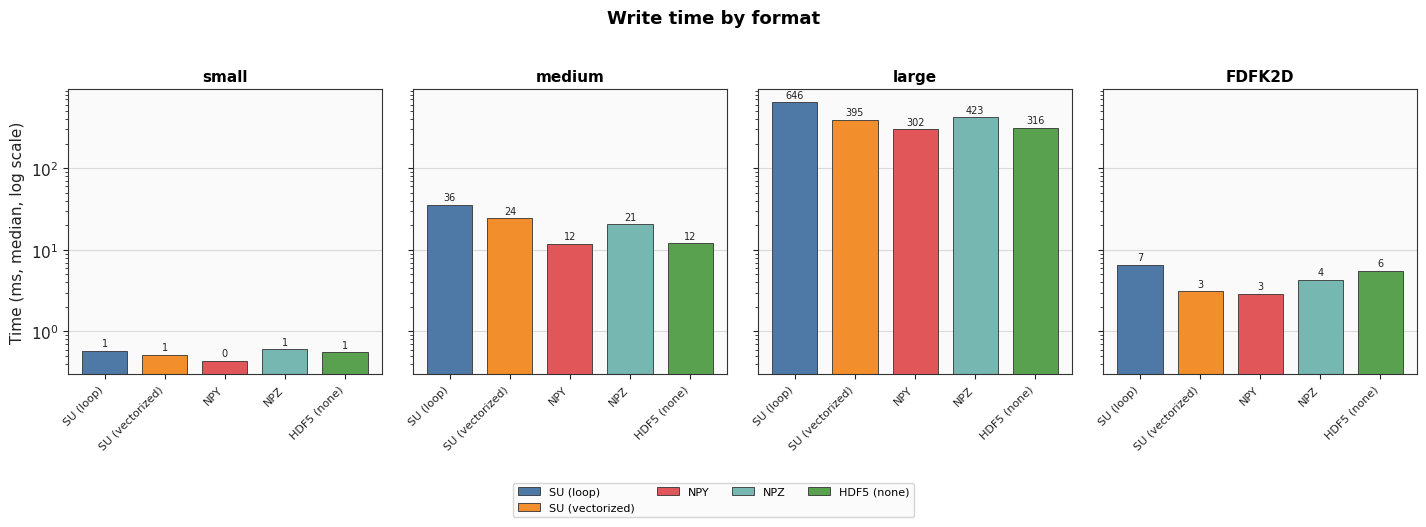

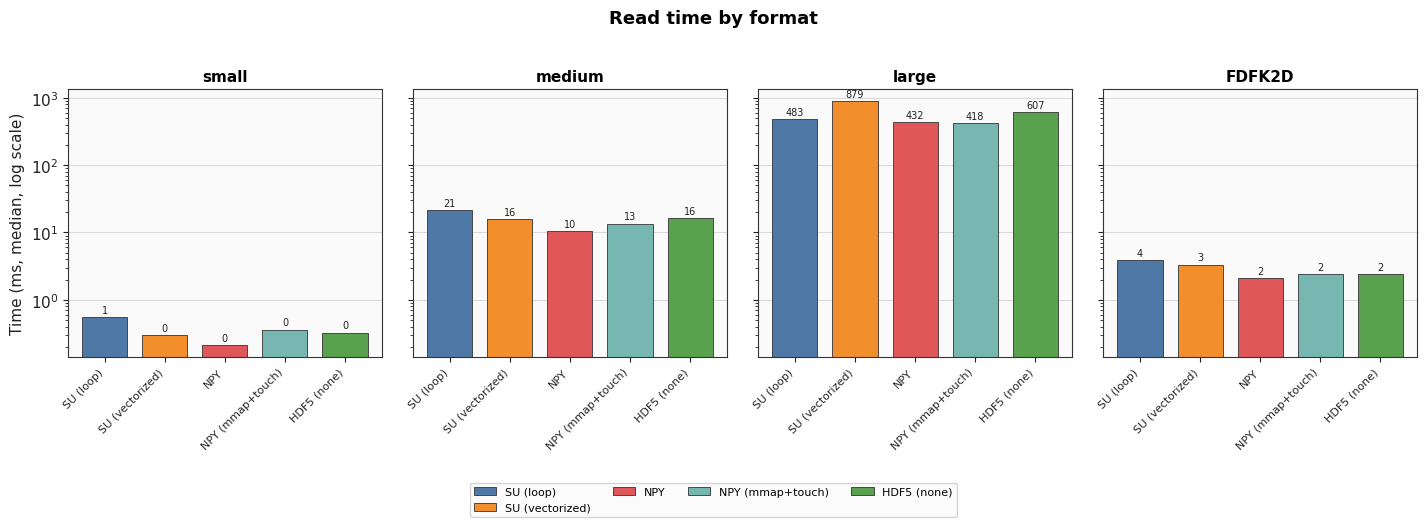

In [8]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#fafafa",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "grid.color": "#bbbbbb",
    "grid.linestyle": "-",
    "font.size": 11,
})

# High-contrast, colorblind-friendly (Tableau 10)
METHOD_COLORS.clear()
_PALETTE[:] = [
    "#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F",
    "#EDC948", "#B07AA1", "#FF9DA7", "#9C755F", "#BAB0AC",
]


def plot_timings(
    results: dict[str, dict[str, BenchResult]],
    title: str,
    methods: list[str] | None = None,
):
    """Grouped bar chart — one panel per data size for readability."""
    size_labels = list(results.keys())
    if methods is None:
        methods = list(results[size_labels[0]].keys())
    register_method_colors(methods)
    n_sizes, n_methods = len(size_labels), len(methods)

    fig, axes = plt.subplots(1, n_sizes, figsize=(3.6 * n_sizes, 4.5), sharey=True)
    if n_sizes == 1:
        axes = [axes]

    for ax, size in zip(axes, size_labels):
        times_ms = [results[size][m].median_ms if m in results[size] else np.nan for m in methods]
        x = np.arange(n_methods)
        colors = [METHOD_COLORS[m] for m in methods]
        bars = ax.bar(x, times_ms, color=colors, edgecolor="#333333", linewidth=0.6, width=0.75)
        ax.set_yscale("log")
        ax.set_title(size.split("(")[0].strip(), fontsize=11, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(methods, rotation=45, ha="right", fontsize=8)
        ax.grid(axis="y", alpha=0.5, zorder=0)
        ax.set_axisbelow(True)
        for bar, t in zip(bars, times_ms):
            if np.isfinite(t) and t > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() * 1.08,
                    f"{t:.0f}",
                    ha="center",
                    va="bottom",
                    fontsize=7,
                    color="#222222",
                )

    axes[0].set_ylabel("Time (ms, median, log scale)")
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.02)
    handles = [
        plt.Rectangle((0, 0), 1, 1, fc=METHOD_COLORS[m], ec="#333333", lw=0.6)
        for m in methods
    ]
    fig.legend(handles, methods, loc="upper center", bbox_to_anchor=(0.5, -0.02),
               ncol=min(4, n_methods), fontsize=8, frameon=True)
    fig.tight_layout()
    return fig


core_write = [m for m in ["SU (loop)", "SU (vectorized)", "NPY", "NPZ", "HDF5 (none)"] if m in write_methods]
core_read = [
    m for m in ["SU (loop)", "SU (vectorized)", "NPY", "NPY (mmap+touch)", "HDF5 (none)"]
    if any(m in read_results[s] for s in read_results)
]

plot_timings(write_results, "Write time by format", core_write)
plt.show()
plot_timings(read_results, "Read time by format", core_read)
plt.show()


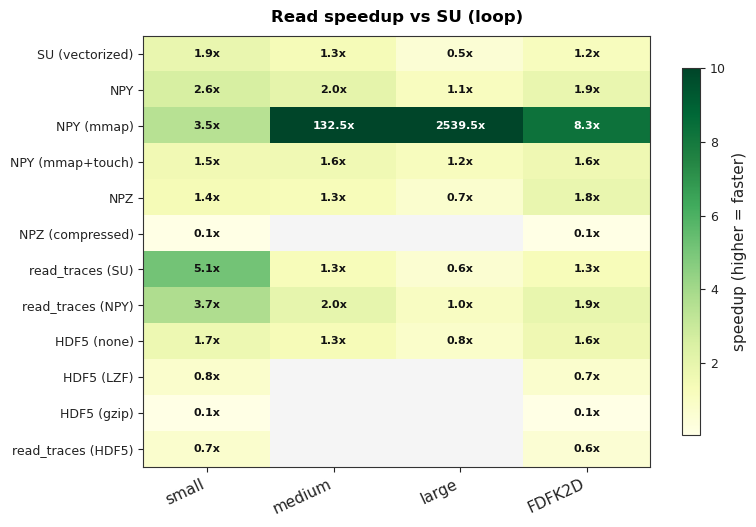

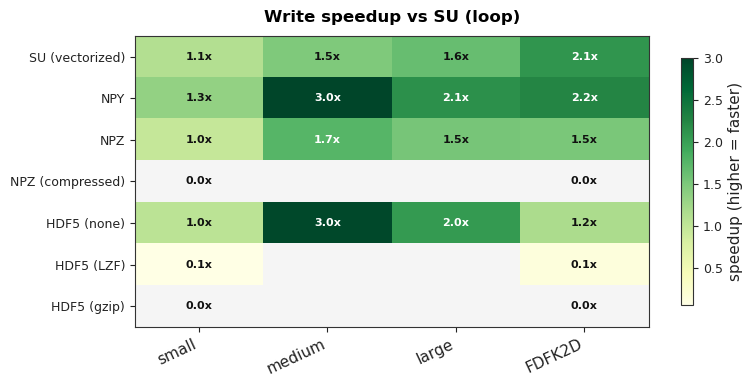

In [14]:
def speedup_heatmap(results, baseline="SU (loop)", title="Speedup vs SU (loop)"):
    size_labels = list(results.keys())
    methods = [
        m for m in results[size_labels[-1]].keys()
        if m != baseline and baseline in results[size_labels[-1]]
    ]
    mat = np.zeros((len(methods), len(size_labels)))
    for j, s in enumerate(size_labels):
        if baseline not in results[s]:
            continue
        t0 = results[s][baseline].median_s
        for i, m in enumerate(methods):
            if m in results[s]:
                mat[i, j] = t0 / results[s][m].median_s

    fig, ax = plt.subplots(figsize=(max(8, 1.2 * len(size_labels)), max(4, 0.45 * len(methods))))
    cmap = plt.get_cmap("YlGn").copy()
    cmap.set_under("#f5f5f5")
    vmax = max(2.0, float(np.nanmax(mat)) if mat.size else 2.0)
    # optional cap: 10x
    vmax = min(vmax, 10.0)
    im = ax.imshow(mat, aspect="auto", cmap=cmap, vmin=0.05, vmax=vmax)
    ax.set_xticks(range(len(size_labels)))
    ax.set_xticklabels([s.split("(")[0].strip() for s in size_labels], rotation=25, ha="right")
    ax.set_yticks(range(len(methods)))
    ax.set_yticklabels(methods, fontsize=9)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    for i in range(len(methods)):
        for j in range(len(size_labels)):
            val = mat[i, j]
            if not np.isfinite(val) or val <= 0:
                continue
            txt_color = "white" if val > 0.55 * vmax else "#111111"
            ax.text(j, i, f"{val:.1f}x", ha="center", va="center", fontsize=8,
                    color=txt_color, fontweight="bold")
    cbar = fig.colorbar(im, ax=ax, label="speedup (higher = faster)", shrink=0.85)
    cbar.ax.tick_params(labelsize=9)
    fig.tight_layout()
    return fig


speedup_heatmap(read_results, title="Read speedup vs SU (loop)")
plt.show()
speedup_heatmap(write_results, title="Write speedup vs SU (loop)")
plt.show()


## 9. Summary table (largest size)


In [10]:
summary_label = "large (100000x4501)"
baseline = "SU (loop)"
ref_r = read_results[summary_label][baseline].median_s
ref_w = write_results[summary_label][baseline].median_s

print("=" * 88)
print(
    f"{'Method':24s} | {'Read ms':>10s} | {'R speedup':>10s} | "
    f"{'Write ms':>10s} | {'W speedup':>10s} | {'Disk GB':>8s}"
)
print("-" * 88)

write_side_methods = sorted(write_results[summary_label].keys())
for method in write_side_methods:
    r_ms = r_sp = float("nan")
    if method in read_results[summary_label]:
        r_ms = read_results[summary_label][method].median_ms
        r_sp = ref_r / read_results[summary_label][method].median_s
    w_ms = write_results[summary_label][method].median_ms
    w_sp = ref_w / write_results[summary_label][method].median_s
    disk_gb = disk_sizes.get(method, float("nan")) / 1e9
    print(
        f"{method:24s} | {r_ms:10.2f} | {r_sp:9.1f}x | {w_ms:10.2f} | {w_sp:9.1f}x | {disk_gb:8.3f}"
    )

print("-" * 88)
print("Read-only variants (same on-disk files):")
for method in sorted(read_results[summary_label]):
    if method in write_side_methods:
        continue
    r_ms = read_results[summary_label][method].median_ms
    r_sp = ref_r / read_results[summary_label][method].median_s
    print(f"{method:24s} | {r_ms:10.2f} | {r_sp:9.1f}x | {'n/a':>10s} | {'n/a':>10s} | {'n/a':>8s}")

print("=" * 88)
print(f"\nSummary size: {summary_label}")


Method                   |    Read ms |  R speedup |   Write ms |  W speedup |  Disk GB
----------------------------------------------------------------------------------------
HDF5 (none)              |     607.50 |       0.8x |     315.53 |       2.0x |    1.800
NPY                      |     431.93 |       1.1x |     301.51 |       2.1x |    1.800
NPZ                      |     690.41 |       0.7x |     422.96 |       1.5x |    1.800
SU (loop)                |     482.82 |       1.0x |     646.26 |       1.0x |    1.824
SU (vectorized)          |     879.04 |       0.5x |     395.08 |       1.6x |    1.824
----------------------------------------------------------------------------------------
Read-only variants (same on-disk files):
NPY (mmap)               |       0.19 |    2539.5x |        n/a |        n/a |      n/a
NPY (mmap+touch)         |     417.89 |       1.2x |        n/a |        n/a |      n/a
read_traces (NPY)        |     461.21 |       1.0x |        n/a |        n/a 

## 10. Conclusions

1. **NPY** and **SU (vectorized)** lead for full load read/write.
2. **NPY (mmap)** is for lazy/partial access; use plain NPY or mmap+touch for full arrays.
3. **Compressed** NPZ/HDF5 trade write speed for smaller files.
4. Prefer **NPY** for internal checkpoints, **SU (vectorized)** for SU toolchain interop.


In [11]:
shutil.rmtree(tmpdir, ignore_errors=True)
print(f"Cleaned up {tmpdir}")


Cleaned up /var/folders/ln/v188ylkn2qq1nqsd7wyj2w9m0000gn/T/io_bench_p73qtc97
